# IbrahimNet -  MonReader Page Flip Detection

- With AdamW instead of Adam approche 
- Fix dropout instead of 0.5 I used 0.25
- ReduceLROnPlateau (Automatically reduce learning rate when validation loss plateaus)
- Early Stopping (Automatically stops training when validation loss stops improving) 
- Better W&B Integration (Track my code performance )

In [17]:
import os
import torch
import torch.nn as nn
import torchvision
import torchvision.models as tm
from torchvision import transforms
from torch.utils.data import DataLoader, random_split
from torch.optim.lr_scheduler import ReduceLROnPlateau  # ⭐ NEW

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from tqdm import tqdm
import matplotlib.image as mpimg
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✓ Using device: {device}')

✓ Using device: cpu


## W&B Integration

In [ ]:


# For this notebook, we'll initialize W&B without API key requirement
import wandb

try:
    wandb.login(key=os.getenv('WANDB_API_KEY', None), relogin=True)
    wandb_available = True
    print('✓ W&B login successful')
except:
    wandb_available = False
    print('⚠ W&B not available. Continuing with manual tracking...')

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


✓ W&B login successful


## Initialize W&B 

In [19]:
# Initialize W&B run with configuration
if wandb_available:
    run = wandb.init(
        project='MonReader-PageFlip',
        entity=None,  # Leave None if you don't have a team
        name='IbrahimNet_v2_Enhanced',
        config={
            'batch_size': 32,
            'learning_rate': 0.001,
            'optimizer': 'AdamW',  # ⭐ Changed from Adam
            'scheduler': 'ReduceLROnPlateau',  # ⭐ NEW
            'dropout_rate': 0.5,  # ⭐ NEW
            'early_stopping_patience': 5,  # ⭐ NEW
            'epochs': 50,
            'architecture': 'IbrahimNet_with_Dropout',
        },
        tags=['page-flip-detection', 'enhanced', 'dropout', 'early-stopping'],
    )
    print(f'✓ W&B run initialized: {run.name}')
    print(f'✓ Dashboard: {run.url}')
else:
    print('✓ Using manual experiment tracking')

epoch,▁▅█
learning_rate,▁▁▁
train_accuracy,▁▆█
train_loss,█▂▁
val_accuracy,▁▇█
val_loss,█▃▁
epoch,3
learning_rate,0.001
train_accuracy,0.80482
train_loss,0.43067
val_accuracy,0.81285


✓ W&B run initialized: IbrahimNet_v2_Enhanced
✓ Dashboard: https://wandb.ai/brahiml_chaoudi-apziva/MonReader-PageFlip/runs/n3ptnozk


## Update these paths to match your MonReader dataset location
Update these paths to match your MonReader dataset location.

In [20]:
# Set folder paths - UPDATE THIS TO YOUR DATA PATH
base_dir = r'C:\Users\Dell\Desktop\APZIVA\MonReader Project\images\images'
train_dir = os.path.join(base_dir, 'training')  # Training data path
test_dir = os.path.join(base_dir, 'testing')    # Test data path

# Verify paths exist
print('📂 Data Paths:')
print(f'  Train: {train_dir} | Exists: {os.path.exists(train_dir)}')
print(f'  Test:  {test_dir} | Exists: {os.path.exists(test_dir)}')

📂 Data Paths:
  Train: C:\Users\Dell\Desktop\APZIVA\MonReader Project\images\images\training | Exists: True
  Test:  C:\Users\Dell\Desktop\APZIVA\MonReader Project\images\images\testing | Exists: True


##  Data Transforms
Augmentation for training, normalization for both train/test. Image resized to 224x224 for optimal processing.

In [21]:
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])

print('✓ Data transforms defined')

✓ Data transforms defined


## Load and Split Datasets
Split training data: 85% train, 15% validation. This helps prevent overfitting.

In [38]:
# Load datasets
full_train_dataset = torchvision.datasets.ImageFolder(train_dir, transform=train_transform)
test_dataset = torchvision.datasets.ImageFolder(test_dir, transform=test_transform)

class_names = full_train_dataset.classes
print(f'Classes detected: {class_names}')

# Split training data into train and validation (85% train, 15% val)
val_size = int(0.15 * len(full_train_dataset))
train_size = len(full_train_dataset) - val_size
train_dataset, val_dataset = random_split(
    full_train_dataset, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(4231)
)

print(f'\n Dataset Sizes:')
print(f'  Training:   {len(train_dataset)}')
print(f'  Validation: {len(val_dataset)}')
print(f'  Test:       {len(test_dataset)}')

# Create data loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f'\n DataLoader Batches:')
print(f'  Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Classes detected: ['flip', 'notflip']

 Dataset Sizes:
  Training:   2034
  Validation: 358
  Test:       597

 DataLoader Batches:
  Train: 64 | Val: 12 | Test: 19


##  plot Sample Images
Display sample flip vs notflip images to verify data quality.

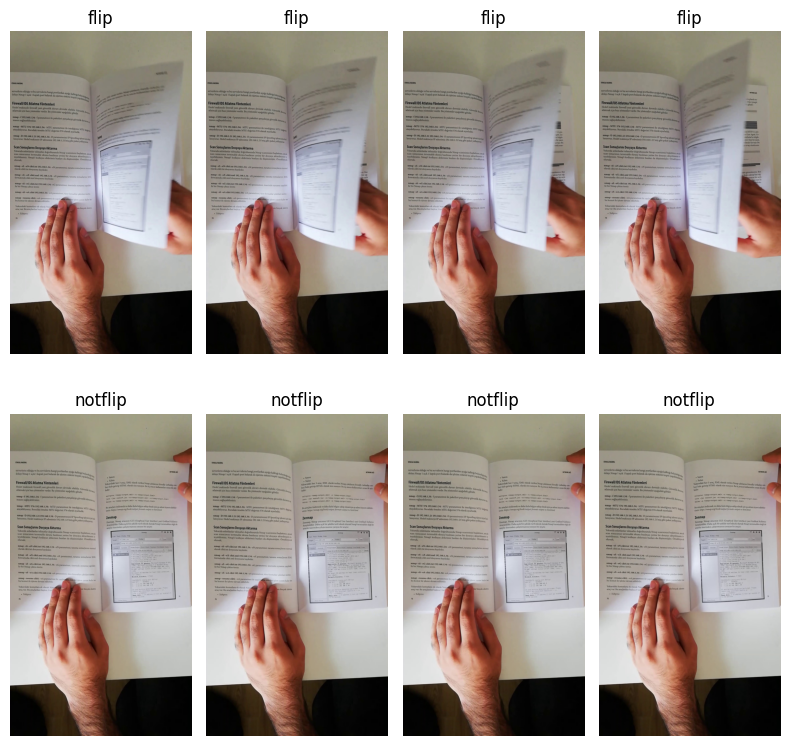

✓ Sample images displayed


In [23]:
%matplotlib inline

flip_dir = os.path.join(train_dir, 'flip')
notflip_dir = os.path.join(train_dir, 'notflip')

nrows, ncols = 2, 4
pic_index = 8

fig = plt.gcf()
fig.set_size_inches(ncols*2, nrows*4)

flip_pix = [os.path.join(flip_dir, fname)
            for fname in os.listdir(flip_dir)[pic_index-4:pic_index]]
not_flip_pix = [os.path.join(notflip_dir, fname)
                for fname in os.listdir(notflip_dir)[pic_index-4:pic_index]]

for i, img_path in enumerate(flip_pix + not_flip_pix):
    sp = plt.subplot(nrows, ncols, i + 1)
    sp.title.set_text(os.path.basename(os.path.dirname(img_path)))
    sp.axis('Off')
    img = mpimg.imread(img_path)
    plt.imshow(img)

plt.tight_layout()
plt.show()
print('✓ Sample images displayed')

##  IbrahimNet Model - With dropout
Added dropout layers to reduce overfitting. Dropout rates are higher in FC layers (0.5) and lighter in conv layers (0.25).

In [ ]:
class IbrahimNet(nn.Module):
    """IbrahimNet with Dropout for Page Flip Detection"""
    def __init__(self, num_classes=2, dropout_rate=0.5):
        super(IbrahimNet, self).__init__()
        self.model = nn.Sequential(
            # Block 1: Conv + Dropout
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Dropout(dropout_rate * 0.5),  # 0.25
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Block 2: Conv + Dropout
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Dropout(dropout_rate * 0.5),  # 0.25
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Block 3: Conv + Dropout
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Dropout(dropout_rate * 0.5),  # 0.25
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Flatten + FC layers with Heavy Dropout
            nn.Flatten(),
            nn.Linear(128 * (IMG_SIZE // 8) * (IMG_SIZE // 8), 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),  # big dropout 0.5 in FC
            
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        return self.model(x)

# Create model instance
model = IbrahimNet(num_classes=len(class_names), dropout_rate=0.5).to(device)
print('✓ IbrahimNet model created with Dropout')
print(model)

✓ IbrahimNet model created with Dropout
IbrahimNet(
  (model): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Dropout(p=0.25, inplace=False)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): Dropout(p=0.25, inplace=False)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
    (10): Dropout(p=0.25, inplace=False)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Flatten(start_dim=1, end_dim=-1)
    (13): Linear(in_features=100352, out_features=256, bias=True)
    (14): ReLU()
    (15): Dropout(p=0.5, inplace=False)
    (16): Linear(in_features=256, out_features=2, bias=True)
  )
)


In [25]:
# Test model output shape
dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
output = model(dummy_input)
print(f'✓ Output shape: {output.shape}  (should be [1, {len(class_names)}])')

✓ Output shape: torch.Size([1, 2])  (should be [1, 2])


##  Early Stopping Mechanism 
Automatically stops training when validation loss stops improving. Saves time and prevents overfitting.

In [ ]:
class EarlyStopping:
    """Early Stopping to prevent overfitting"""
    def __init__(self, patience=5, verbose=True, delta=0.001):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.delta = delta
        self.best_model_path = './best_model_monreader.pt'
    
    def __call__(self, val_loss, model):
        score = -val_loss
        
        if self.best_score is None:
            self.best_score = score
            torch.save(model.state_dict(), self.best_model_path)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'⚠️  EarlyStopping counter: {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
                print(f'✓ Best model saved to: {self.best_model_path}')
        else:
            self.best_score = score
            self.counter = 0
            torch.save(model.state_dict(), self.best_model_path)

early_stopping = EarlyStopping(patience=5, verbose=False)
print('✓ Early Stopping initialized')
 

✓ Early Stopping initialized


##  Optimizer & Scheduler
**AdamW** : More stable than Adam with weight decay regularization.

**ReduceLROnPlateau** : Automatically reduce learning rate when validation loss plateaus.

In [ ]:
#  AdamW Optimizer (replaces Adam)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4  # L2 regularization
)

#  ReduceLROnPlateau Scheduler
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,      # Reduce LR by 50%
    patience=3,      # Wait 3 epochs
    min_lr=1e-6
)

# Loss function
criterion = nn.CrossEntropyLoss()

print('✓ Optimizer: AdamW with weight_decay=1e-4')
print('✓ Scheduler: ReduceLROnPlateau')
print('✓ Loss: CrossEntropyLoss')

✓ Optimizer: AdamW with weight_decay=1e-4
✓ Scheduler: ReduceLROnPlateau
✓ Loss: CrossEntropyLoss


## Training Function
Trains the model for one epoch. Returns average loss and accuracy.

In [28]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()  # Enable dropout, batch norm updates
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in tqdm(dataloader, desc='Training', leave=False):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

print('✓ Training function defined')

✓ Training function defined


##  Evaluation Function
Evaluates model on validation/test set. Disables dropout during evaluation.

In [29]:
def evaluate(model, dataloader, criterion, device):
    """Evaluate model on validation/test set"""
    model.eval()  # Disable dropout, freeze batch norm
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc='Evaluating', leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc, np.array(all_preds), np.array(all_labels)

print('✓ Evaluation function defined')

✓ Evaluation function defined


##  Main Training Loop
Complete training with AdamW + Dropout + ReduceLROnPlateau + Early Stopping + Validation Tracking

In [30]:
# Initialize tracking lists
train_losses = []
val_losses = []
train_accs = []
val_accs = []
learning_rates = []
epochs_list = []

print('✓ Tracking lists initialized')

✓ Tracking lists initialized


In [ ]:
num_epochs = 5  # Maximum epochs

print('\n' + '='*80)
print('TRAINING START - With AdamW + Dropout + ReduceLROnPlateau + Early Stopping')
print('='*80 + '\n')

for epoch in range(num_epochs):
    # Train
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validate
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
    
    # Get current learning rate
    current_lr = optimizer.param_groups[0]['lr']
    
    # Log metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    learning_rates.append(current_lr)
    epochs_list.append(epoch + 1)
    
    #  ReduceLROnPlateau: Adjust LR based on validation loss
    scheduler.step(val_loss)
    
    #  Early Stopping: Check if should stop
    early_stopping(val_loss, model)
    
    # Log to W&B
    if wandb_available:
        wandb.log({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'train_accuracy': train_acc,
            'val_accuracy': val_acc,
            'learning_rate': current_lr,
        })
    
    # Print progress every 5 epochs
    if (epoch + 1) % 5 == 0 or early_stopping.early_stop:
        print(f'Epoch {epoch+1:3d}/{num_epochs} | '
              f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | '
              f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | '
              f'LR: {current_lr:.6f}')
    
    if early_stopping.early_stop:
        print(f'\n✓ Early stopping triggered at epoch {epoch+1}')
        break

print('\n' + '='*80)
print('✓ Training Completed!')
print('='*80)


TRAINING START - With AdamW + Dropout + ReduceLROnPlateau + Early Stopping



Epoch   5/5 | Train Loss: 0.3100 | Train Acc: 0.8609 | Val Loss: 0.3212 | Val Acc: 0.8994 | LR: 0.001000

✓ Training Completed!


## Train Metrics Visualization
Four comprehensive plots showing:
1. **Training vs Validation Loss** - Main indicator of overfitting
2. **Training vs Validation Accuracy** - Model performance
3. **Learning Rate Schedule** - ReduceLROnPlateau effect
4. **Overfitting Indicator** - Difference between validation and training loss

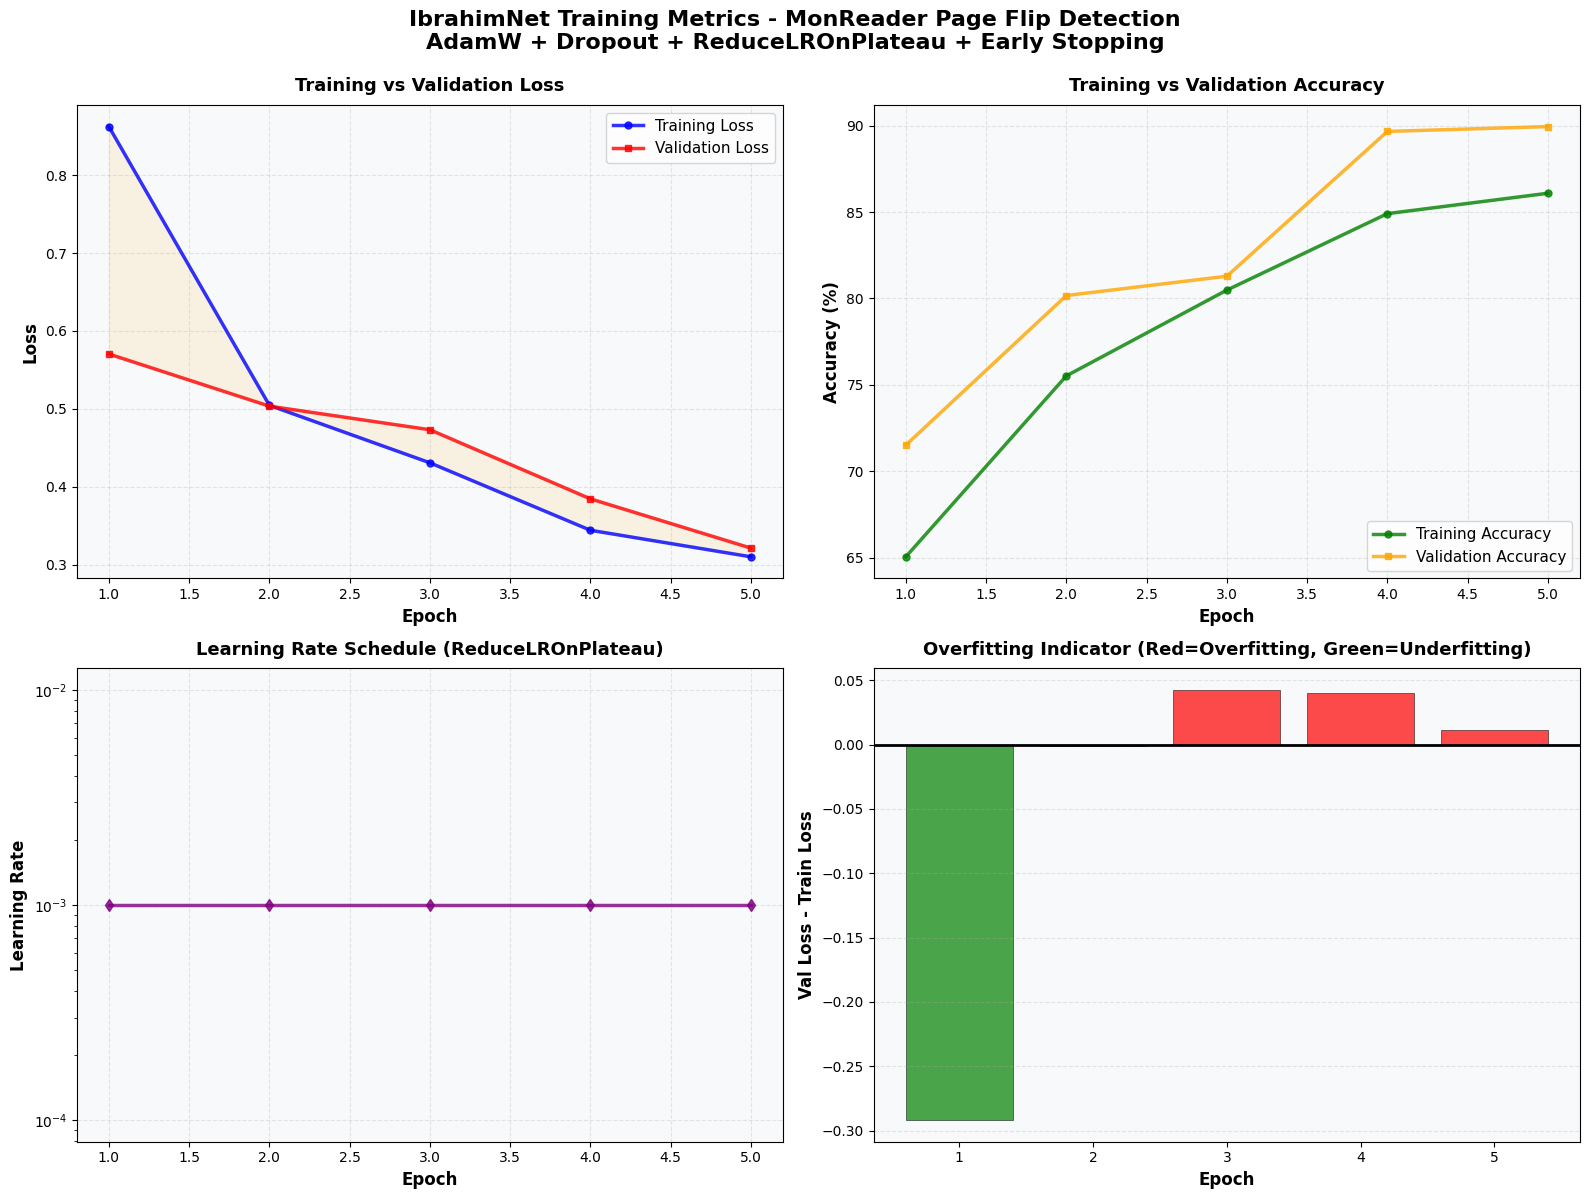

✓ Training metrics plot saved: ./monreader_training_metrics.png


In [ ]:
# Create figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('IbrahimNet Training Metrics - MonReader Page Flip Detection\n'
             'AdamW + Dropout + ReduceLROnPlateau + Early Stopping',
             fontsize=16, fontweight='bold', y=0.995)

# Plot 1: Training vs Validation Loss  MAIN PLOT
axes[0, 0].plot(epochs_list, train_losses, 'b-o', label='Training Loss',
               linewidth=2.5, markersize=5, alpha=0.8)
axes[0, 0].plot(epochs_list, val_losses, 'r-s', label='Validation Loss',
               linewidth=2.5, markersize=5, alpha=0.8)
axes[0, 0].fill_between(epochs_list, train_losses, val_losses, alpha=0.1, color='orange')
axes[0, 0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Loss', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Training vs Validation Loss', fontsize=13, fontweight='bold', pad=10)
axes[0, 0].legend(fontsize=11, loc='upper right')
axes[0, 0].grid(True, alpha=0.3, linestyle='--')
axes[0, 0].set_facecolor('#f8f9fa')

# Plot 2: Training vs Validation Accuracy
axes[0, 1].plot(epochs_list, [x*100 for x in train_accs], 'g-o', label='Training Accuracy',
               linewidth=2.5, markersize=5, alpha=0.8)
axes[0, 1].plot(epochs_list, [x*100 for x in val_accs], 'orange', marker='s',
               label='Validation Accuracy', linewidth=2.5, markersize=5, alpha=0.8)
axes[0, 1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Training vs Validation Accuracy', fontsize=13, fontweight='bold', pad=10)
axes[0, 1].legend(fontsize=11, loc='lower right')
axes[0, 1].grid(True, alpha=0.3, linestyle='--')
axes[0, 1].set_facecolor('#f8f9fa')

# Plot 3: Learning Rate Schedule
axes[1, 0].plot(epochs_list, learning_rates, 'purple', marker='d',
               linewidth=2.5, markersize=6, alpha=0.8)
axes[1, 0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Learning Rate', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Learning Rate Schedule (ReduceLROnPlateau)', fontsize=13, fontweight='bold', pad=10)
axes[1, 0].grid(True, alpha=0.3, linestyle='--')
axes[1, 0].set_yscale('log')
axes[1, 0].set_facecolor('#f8f9fa')

# Plot 4: Overfitting Indicator
loss_diff = [val - train for train, val in zip(train_losses, val_losses)]
colors = ['red' if x > 0 else 'green' for x in loss_diff]
axes[1, 1].bar(epochs_list, loss_diff, color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)
axes[1, 1].axhline(y=0, color='black', linestyle='-', linewidth=2)
axes[1, 1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Val Loss - Train Loss', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Overfitting Indicator (Red=Overfitting, Green=Underfitting)',
                    fontsize=13, fontweight='bold', pad=10)
axes[1, 1].grid(True, alpha=0.3, linestyle='--', axis='y')
axes[1, 1].set_facecolor('#f8f9fa')

plt.tight_layout()
plt.savefig('./monreader_training_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Training metrics plot saved: ./monreader_training_metrics.png')

## Load Best Model & Evaluate
Load the best model saved during training and evaluate on test set.

In [ ]:
# Load best model
model.load_state_dict(torch.load(early_stopping.best_model_path, weights_only=True))
print(f'✓ Best model loaded from: {early_stopping.best_model_path}')

# Evaluate on test set
test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion, device)

print(f'\n' + '='*60)
print('FINAL TEST PERFORMANCE')
print('='*60)
print(f'Test Loss:     {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'F1 Score:      {f1_score(test_labels, test_preds):.4f}   Main Metric')
print('='*60)

✓ Best model loaded from: ./best_model_monreader.pt



FINAL TEST PERFORMANCE
Test Loss:     0.2711
Test Accuracy: 0.9146 (91.46%)
F1 Score:      0.9217   Main Metric


In [34]:
# Print detailed classification report
print('\n' + '='*60)
print('CLASSIFICATION REPORT')
print('='*60)
print(classification_report(test_labels, test_preds,
                          target_names=class_names,
                          digits=4))

# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
print('\nConfusion Matrix:')
print(cm)


CLASSIFICATION REPORT
              precision    recall  f1-score   support

        flip     0.9723    0.8483    0.9061       290
     notflip     0.8721    0.9772    0.9217       307

    accuracy                         0.9146       597
   macro avg     0.9222    0.9127    0.9139       597
weighted avg     0.9208    0.9146    0.9141       597


Confusion Matrix:
[[246  44]
 [  7 300]]


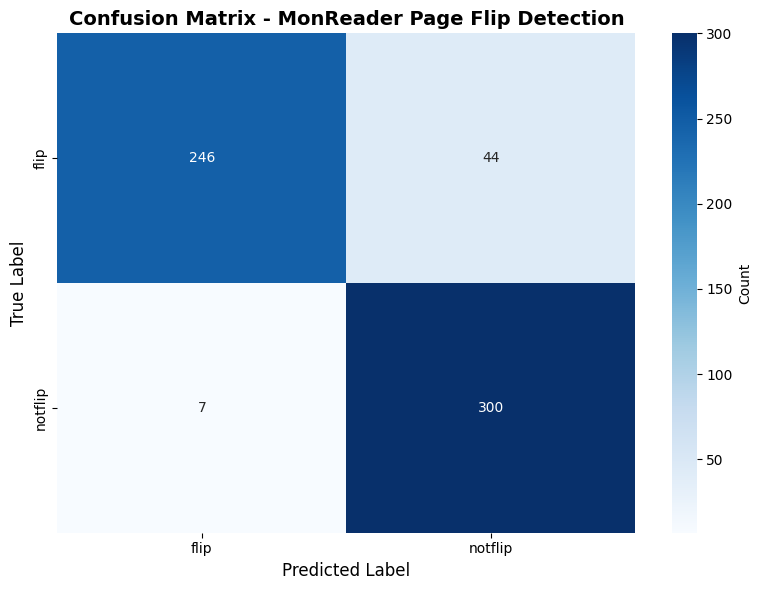

✓ Confusion matrix plot saved: ./monreader_confusion_matrix.png


In [35]:
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - MonReader Page Flip Detection', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('./monreader_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Confusion matrix plot saved: ./monreader_confusion_matrix.png')

In [36]:
if wandb_available:
    # Log final metrics
    wandb.log({
        'test_loss': test_loss,
        'test_accuracy': test_acc,
        'f1_score': f1_score(test_labels, test_preds),
    })
    
    # Save plots to W&B
    wandb.log({'training_metrics': wandb.Image('./monreader_training_metrics.png')})
    wandb.log({'confusion_matrix': wandb.Image('./monreader_confusion_matrix.png')})
    
    wandb.finish()
    print('✓ W&B run finished and all artifacts uploaded!')
else:
    print('⚠ W&B not available - metrics saved locally only')

epoch,▁▃▅▆█
f1_score,▁
learning_rate,▁▁▁▁▁
test_accuracy,▁
test_loss,▁
train_accuracy,▁▄▆██
train_loss,█▃▃▁▁
val_accuracy,▁▄▅██
val_loss,█▆▅▃▁
epoch,5
f1_score,0.92166


✓ W&B run finished and all artifacts uploaded!
